In [ ]:
import requests
x = requests.get("https://api.openparliament.ca/politicians/yvan-baker/")
print(x.text)

<!doctype html>
<html class="no-js" lang="en">
<head>
    <meta charset="utf-8">
    <meta http-equiv="x-ua-compatible" content="ie=edge">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Politician | openparliament.ca</title>
  <link rel="icon" type="image/png" href="/static/images/favicon.png">

  <link rel="stylesheet" href="/static/CACHE/css/output.7d6f27648419.css" type="text/css">
  
    
    <script>
    window.sentryOnLoad = function () {
      Sentry.init({
          
	tracesSampleRate: 0.01,
	ignoreErrors: [
		"Failed to fetch",
		"Non-Error promise rejection captured with value: Object Not Found Matching"
	],
	replaysSessionSampleRate: 0,
	replaysOnErrorSampleRate: 0.2,
	/* integrations: [
		new Sentry.browserTracingIntegration(),
		new Sentry.replayIntegration({ maskAllText: false,blockAllMedia: false})
	] */

      });
    };
    </script>
    
  <script src="https://js.sentry-cdn.com/5621926099e6734dc120d3d19acd5e8a.min.js" crossorigin="

In [8]:
import beautifulsoup
import selenium

ModuleNotFoundError: No module named 'beautifulsoup'

In [ ]:
import requests
import json
from typing import Dict, List, Optional

class OpenParliamentAPI:
    """
    Python client for the openparliament.ca API
    """
    
    BASE_URL = "https://openparliament.ca/api"
    
    def __init__(self):
        self.session = requests.Session()
        self.session.headers.update({
            'User-Agent': 'Mozilla/5.0 (Python openparliament-client)'
        })
    
    # ============ MEMBERS ============
    
    def get_members(self, session_id: Optional[int] = None) -> List[Dict]:
        """
        Get list of MPs/members
        Optional: filter by session_id
        """
        endpoint = f"{self.BASE_URL}/members/"
        params = {}
        if session_id:
            params['session'] = session_id
        
        response = self.session.get(endpoint, params=params)
        response.raise_for_status()
        return response.json()
    
    def get_member(self, member_id: int) -> Dict:
        """Get a specific member by ID"""
        endpoint = f"{self.BASE_URL}/members/{member_id}/"
        response = self.session.get(endpoint)
        response.raise_for_status()
        return response.json()
    
    # ============ BILLS ============
    
    def get_bills(self, session_id: Optional[int] = None) -> List[Dict]:
        """Get all bills, optionally filtered by session"""
        endpoint = f"{self.BASE_URL}/bills/"
        params = {}
        if session_id:
            params['session'] = session_id
        
        response = self.session.get(endpoint, params=params)
        response.raise_for_status()
        return response.json()
    
    def get_bill(self, bill_id: int) -> Dict:
        """Get details of a specific bill"""
        endpoint = f"{self.BASE_URL}/bills/{bill_id}/"
        response = self.session.get(endpoint)
        response.raise_for_status()
        return response.json()
    
    # ============ STATEMENTS (Hansard/Debates) ============
    
    def get_statements(
        self, 
        member_id: Optional[int] = None,
        bill_id: Optional[int] = None,
        session_id: Optional[int] = None,
        limit: int = 100,
        offset: int = 0
    ) -> Dict:
        """
        Get parliamentary statements (hansard records)
        Can filter by member, bill, or session
        """
        endpoint = f"{self.BASE_URL}/statements/"
        params = {
            'limit': limit,
            'offset': offset
        }
        
        if member_id:
            params['member'] = member_id
        if bill_id:
            params['bill'] = bill_id
        if session_id:
            params['session'] = session_id
        
        response = self.session.get(endpoint, params=params)
        response.raise_for_status()
        return response.json()
    
    def get_statement(self, statement_id: int) -> Dict:
        """Get a specific statement"""
        endpoint = f"{self.BASE_URL}/statements/{statement_id}/"
        response = self.session.get(endpoint)
        response.raise_for_status()
        return response.json()
    
    # ============ VOTES ============
    
    def get_votes(
        self,
        bill_id: Optional[int] = None,
        member_id: Optional[int] = None,
        session_id: Optional[int] = None
    ) -> List[Dict]:
        """Get voting records"""
        endpoint = f"{self.BASE_URL}/votes/"
        params = {}
        
        if bill_id:
            params['bill'] = bill_id
        if member_id:
            params['member'] = member_id
        if session_id:
            params['session'] = session_id
        
        response = self.session.get(endpoint, params=params)
        response.raise_for_status()
        return response.json()
    
    # ============ PARTIES ============
    
    def get_parties(self) -> List[Dict]:
        """Get all political parties"""
        endpoint = f"{self.BASE_URL}/parties/"
        response = self.session.get(endpoint)
        response.raise_for_status()
        return response.json()
    
    # ============ SESSIONS ============
    
    def get_sessions(self) -> List[Dict]:
        """Get all parliamentary sessions"""
        endpoint = f"{self.BASE_URL}/sessions/"
        response = self.session.get(endpoint)
        response.raise_for_status()
        return response.json()


# ============ USAGE EXAMPLES ============

def main():
    api = OpenParliamentAPI()
    
    # Get all current members
    print("Fetching members...")
    members = api.get_members()
    print(f"Found {len(members)} members")
    
    # Get a specific member
    if members:
        member_id = members[0]['id']
        member = api.get_member(member_id)
        print(f"Member: {member['name']}")
    
    # Get all bills
    print("\nFetching bills...")
    bills = api.get_bills()
    print(f"Found {len(bills)} bills")
    
    # Get statements by a member
    print("\nFetching statements...")
    statements = api.get_statements(member_id=member_id, limit=10)
    print(f"Found {statements['count']} total statements")
    for stmt in statements['results']:
        print(f"- {stmt['member']['name']}: {stmt['text'][:80]}...")
    
    # Get votes
    print("\nFetching votes...")
    votes = api.get_votes(member_id=member_id)
    print(f"Found {len(votes)} votes")
    
    # Get parties
    print("\nFetching parties...")
    parties = api.get_parties()
    for party in parties:
        print(f"- {party['name']} ({party['short_name']})")


if __name__ == '__main__':
    main()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#ai generated
# intermediate Monte Carlo for grocery pricing (multiple products, weekly horizon)
products = {
    "milk": 3.50,
    "eggs": 2.80,
    "bread": 2.20,
    "chicken": 6.50,
    "rice": 1.90
}

horizon_weeks = 52
n_sims = 20000
dt = 1/52
mu_g = 0.04  # annual drift in grocery prices
sigma_g = 0.12  # annual volatility

# simulate log-normal paths per product
prices = {}
for name, p0 in products.items():
    Z = np.random.standard_normal((n_sims, horizon_weeks))
    log_returns = (mu_g - 0.5*sigma_g**2)*dt + sigma_g*np.sqrt(dt)*Z
    log_paths = np.cumsum(log_returns, axis=1)
    sims = p0 * np.exp(log_paths)
    sims = np.column_stack([np.full(n_sims, p0), sims])  # include t=0
    prices[name] = sims

# compute basket cost
basket0 = sum(products.values())
basket_paths = np.zeros((n_sims, horizon_weeks+1))
for name in products:
    basket_paths += prices[name]

# stats at end
basket_T = basket_paths[:, -1]
summary = {
    "start_cost": basket0,
    "mean_end_cost": basket_T.mean(),
    "median_end_cost": np.median(basket_T),
    "5th_pct_end_cost": np.percentile(basket_T, 5),
    "95th_pct_end_cost": np.percentile(basket_T, 95),
    "prob_increase_>10%": np.mean(basket_T >= basket0*1.10),
    "prob_increase_>20%": np.mean(basket_T >= basket0*1.20),
}

print("grocery basket MC summary:", summary)

# plot sample trajectories
plt.figure(figsize=(8, 5))
for i in range(50):
    plt.plot(np.linspace(0, horizon_weeks, horizon_weeks+1), basket_paths[i], color="gray", alpha=0.1)
plt.plot(np.linspace(0, horizon_weeks, horizon_weeks+1), np.mean(basket_paths, axis=0), color="blue", linewidth=2, label="mean")
plt.title("Grocery Basket Price Monte Carlo Trajectories")
plt.xlabel("Weeks")
plt.ylabel("Basket Price")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'np' is not defined

E[ST] approx 105.18887067279469
Std[ST] approx 21.208355055866583


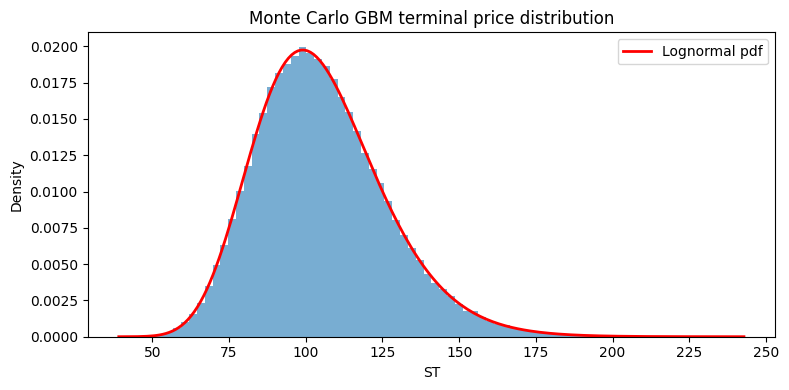